## 1. Setup

In [1]:
import sys
import json
from pathlib import Path
from pprint import pprint

In [2]:
PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

RUNS_DIR = Path("runs")
ONTOLOGY_PATH = "../data/ontology/ContextOntology-COInd4.owl"
REPORTS_DIR = Path("evaluation_reports")
REPORTS_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Runs directory: {RUNS_DIR.resolve()}")
print(f"Reports directory: {REPORTS_DIR.resolve()}")

Project root: C:\Users\Beeclick\Documents\NeoOLAF
Runs directory: C:\Users\Beeclick\Documents\NeoOLAF\examples\runs
Reports directory: C:\Users\Beeclick\Documents\NeoOLAF\examples\evaluation_reports


## 2. Select the latest run

In [3]:
available_runs = sorted([d for d in RUNS_DIR.iterdir() if d.is_dir() and d.name.startswith("run_")])

if not available_runs:
    raise FileNotFoundError(f"No runs found in {RUNS_DIR.resolve()}")

print("Available runs:")
for i, r in enumerate(available_runs):
    print(f"  [{i}] {r.name}")

RUN_DIR = available_runs[-1]
print(f"\nSelected (latest): {RUN_DIR.name}")

Available runs:
  [0] run_20260330_110344

Selected (latest): run_20260330_110344


## 3. Reconstruct PipelineState from artifacts

In [4]:
from neoolaf.core.pipeline_state import PipelineState
from neoolaf.domain.documents import Document, DocumentChunk
from neoolaf.domain.linguistic_expression import LinguisticExpression, Evidence
from neoolaf.domain.enriched_expression import EnrichedExpression, EnrichmentEvidence
from neoolaf.domain.candidates import (
    EntityCandidate, RelationCandidate, AttributeCandidate, EventCandidate, CandidateMention,
)
from neoolaf.domain.relation_assertion import CandidateRelationAssertion
from neoolaf.domain.candidate_triple import CandidateTriple
from neoolaf.domain.ontology_elements import ConceptCandidate, OntologyRelationCandidate
from neoolaf.domain.hierarchy import ConceptHierarchyLink, RelationHierarchyLink
from neoolaf.domain.axiom_schema import AxiomSchemaCandidate
from neoolaf.domain.general_axiom import GeneralAxiomCandidate
from neoolaf.domain.validation_reasoning import ValidationIssue, ValidationReport, ReasoningReport
from neoolaf.domain.completion import CompletionCandidate


def _load_layer_json(run_dir: Path, layer_name: str) -> dict:
    """Load the first JSON file found in a layer folder."""
    layer_dir = run_dir / layer_name
    if not layer_dir.exists():
        print(f"  [SKIP] {layer_name} — folder not found")
        return {}
    json_files = list(layer_dir.glob("*.json"))
    if not json_files:
        print(f"  [SKIP] {layer_name} — no JSON files")
        return {}
    with open(json_files[0], "r", encoding="utf-8") as f:
        data = json.load(f)
    print(f"  [OK]   {layer_name} — {json_files[0].name}")
    return data


def _parse_evidence(items: list) -> list:
    return [
        Evidence(
            chunk_id=e.get("chunk_id", ""),
            chunk_start_char=e.get("chunk_start_char", 0),
            chunk_end_char=e.get("chunk_end_char", 0),
            doc_start_char=e.get("doc_start_char", 0),
            doc_end_char=e.get("doc_end_char", 0),
            snippet=e.get("snippet", ""),
        )
        for e in (items or [])
    ]


def _parse_mention(m: dict) -> CandidateMention:
    return CandidateMention(
        expr_id=m.get("expr_id", ""),
        text=m.get("text", ""),
        evidence=_parse_evidence(m.get("evidence", [])),
    )


def reconstruct_state(run_dir: Path) -> PipelineState:
    print(f"Loading artifacts from: {run_dir}")

    # --- Layer 00: Preprocessing ---
    d00 = _load_layer_json(run_dir, "layer00_preprocessing")
    chunks = [
        DocumentChunk(
            chunk_id=c["chunk_id"],
            text=c.get("text_preview", c.get("text", "")),
            start_char=c.get("start_char", 0),
            end_char=c.get("end_char", 0),
        )
        for c in d00.get("chunks", [])
    ]
    document = Document(
        doc_id=d00.get("doc_id", "unknown"),
        source_path=d00.get("source_path", ""),
        raw_text="",
        pdf_type=d00.get("pdf_type"),
        content_blocks=d00.get("content_blocks", []),
        chunks=chunks,
    )

    # --- Layer 01: Linguistic Expression Extraction ---
    d01 = _load_layer_json(run_dir, "layer01_linguistic_expression_extraction")
    linguistic_expressions = [
        LinguisticExpression(
            expr_id=ex["expr_id"],
            text=ex["text"],
            label=ex.get("label", ""),
            justification=ex.get("justification", ""),
            evidence=_parse_evidence(ex.get("evidence", [])),
            confidence=ex.get("confidence"),
        )
        for ex in d01.get("expressions", [])
    ]

    # --- Layer 02: Candidate Enrichment ---
    d02 = _load_layer_json(run_dir, "layer02_candidate_enrichment")
    enriched_expressions = []
    for ee in d02.get("enriched_expressions", []):
        base = ee.get("base_expression", {})
        enriched_expressions.append(
            EnrichedExpression(
                base_expression=LinguisticExpression(
                    expr_id=base.get("expr_id", ""),
                    text=base.get("text", ""),
                    label=base.get("label", ""),
                    justification=base.get("justification", ""),
                    evidence=_parse_evidence(base.get("evidence", [])),
                    confidence=base.get("confidence"),
                ),
                aliases=ee.get("aliases", []),
                synonyms=ee.get("synonyms", []),
                lexical_variants=ee.get("lexical_variants", []),
                alias_sources=ee.get("alias_sources", {}),
                synonym_sources=ee.get("synonym_sources", {}),
                lexical_variant_sources=ee.get("lexical_variant_sources", {}),
                definition=ee.get("definition"),
                ontology_hints=ee.get("ontology_hints", []),
                enrichment_evidence=[
                    EnrichmentEvidence(
                        source=ev.get("source", ""),
                        content=ev.get("content", ""),
                        reference=ev.get("reference"),
                    )
                    for ev in ee.get("evidence", ee.get("enrichment_evidence", []))
                ],
            )
        )

    # --- Layer 03: Candidate Typing Resolution ---
    d03 = _load_layer_json(run_dir, "layer03_candidate_typing_resolution")

    def _parse_candidates(items, cls):
        return [
            cls(
                candidate_id=c["candidate_id"],
                canonical_label=c.get("canonical_label", ""),
                normalized_label=c.get("normalized_label", ""),
                candidate_type=c.get("candidate_type", ""),
                mentions=[_parse_mention(m) for m in c.get("mentions", [])],
                confidence=c.get("confidence"),
                ontology_hints=c.get("ontology_hints", []),
                definition=c.get("definition"),
                aliases=c.get("aliases", []),
                synonyms=c.get("synonyms", []),
                lexical_variants=c.get("lexical_variants", []),
            )
            for c in (items or [])
        ]

    entity_candidates = _parse_candidates(d03.get("entity_candidates"), EntityCandidate)
    relation_candidates = _parse_candidates(d03.get("relation_candidates"), RelationCandidate)
    attribute_candidates = _parse_candidates(d03.get("attribute_candidates"), AttributeCandidate)
    event_candidates = _parse_candidates(d03.get("event_candidates"), EventCandidate)

    # --- Layer 04: Candidate Relation Extraction ---
    d04 = _load_layer_json(run_dir, "layer04_candidate_relation_extraction")
    candidate_relation_assertions = [
        CandidateRelationAssertion(
            assertion_id=a["assertion_id"],
            relation_candidate_id=a.get("relation_candidate_id", ""),
            relation_label=a.get("relation_label", ""),
            source_candidate_id=a.get("source_candidate_id", ""),
            source_candidate_label=a.get("source_candidate_label", ""),
            source_candidate_type=a.get("source_candidate_type", ""),
            target_candidate_id=a.get("target_candidate_id", ""),
            target_candidate_label=a.get("target_candidate_label", ""),
            target_candidate_type=a.get("target_candidate_type", ""),
            chunk_id=a.get("chunk_id", ""),
            justification=a.get("justification", ""),
            confidence=a.get("confidence"),
            evidence=_parse_evidence(a.get("evidence", [])),
        )
        for a in d04.get("candidate_relation_assertions", [])
    ]

    # --- Layer 05: Candidate Triple Generation ---
    d05 = _load_layer_json(run_dir, "layer05_candidate_triple_generation")

    def _parse_triple(t: dict) -> CandidateTriple:
        subj = t.get("subject", {})
        pred = t.get("predicate", {})
        obj = t.get("object", {})
        return CandidateTriple(
            triple_id=t["triple_id"],
            subject_id=subj.get("id", t.get("subject_id", "")),
            subject_label=subj.get("label", t.get("subject_label", "")),
            subject_type=subj.get("type", t.get("subject_type", "")),
            predicate_id=pred.get("id", t.get("predicate_id", "")),
            predicate_label=pred.get("label", t.get("predicate_label", "")),
            object_id=obj.get("id", t.get("object_id", "")),
            object_label=obj.get("label", t.get("object_label", "")),
            object_type=obj.get("type", t.get("object_type", "")),
            chunk_id=t.get("chunk_id", ""),
            justification=t.get("justification", ""),
            confidence=t.get("confidence"),
            provenance=_parse_evidence(t.get("provenance", [])),
        )

    candidate_triples = [_parse_triple(t) for t in d05.get("candidate_triples", [])]

    # --- Layer 06: Concept Relation Induction ---
    d06 = _load_layer_json(run_dir, "layer06_concept_relation_induction")
    concept_candidates = [
        ConceptCandidate(
            concept_id=c["concept_id"],
            label=c.get("label", ""),
            normalized_label=c.get("normalized_label", ""),
            description=c.get("description"),
            concept_kind=c.get("concept_kind"),
            parent_hint=c.get("parent_hint"),
            source_candidate_ids=c.get("source_candidate_ids", []),
            source_triple_ids=c.get("source_triple_ids", []),
            confidence=c.get("confidence"),
            justification=c.get("justification", ""),
            evidence=_parse_evidence(c.get("evidence", [])),
        )
        for c in d06.get("concept_candidates", [])
    ]
    ontology_relation_candidates = [
        OntologyRelationCandidate(
            relation_id=r["relation_id"],
            label=r.get("label", ""),
            normalized_label=r.get("normalized_label", ""),
            description=r.get("description"),
            domain_hint=r.get("domain_hint"),
            range_hint=r.get("range_hint"),
            source_candidate_ids=r.get("source_candidate_ids", []),
            source_triple_ids=r.get("source_triple_ids", []),
            confidence=r.get("confidence"),
            justification=r.get("justification", ""),
            evidence=_parse_evidence(r.get("evidence", [])),
        )
        for r in d06.get("ontology_relation_candidates", [])
    ]

    # --- Layer 07: Hierarchisation ---
    d07 = _load_layer_json(run_dir, "layer07_hierarchisation")
    concept_hierarchy_links = [
        ConceptHierarchyLink(
            link_id=l["link_id"],
            child_concept_id=l.get("child_concept_id", ""),
            child_label=l.get("child_label", ""),
            parent_concept_id=l.get("parent_concept_id", ""),
            parent_label=l.get("parent_label", ""),
            justification=l.get("justification", ""),
            confidence=l.get("confidence"),
            evidence=_parse_evidence(l.get("evidence", [])),
        )
        for l in d07.get("concept_hierarchy_links", [])
    ]
    relation_hierarchy_links = [
        RelationHierarchyLink(
            link_id=l["link_id"],
            child_relation_id=l.get("child_relation_id", ""),
            child_label=l.get("child_label", ""),
            parent_relation_id=l.get("parent_relation_id", ""),
            parent_label=l.get("parent_label", ""),
            justification=l.get("justification", ""),
            confidence=l.get("confidence"),
            evidence=_parse_evidence(l.get("evidence", [])),
        )
        for l in d07.get("relation_hierarchy_links", [])
    ]

    # --- Layer 08: Axiom Schemata Extraction ---
    d08 = _load_layer_json(run_dir, "layer08_axiom_schemata_extraction")
    axiom_schema_candidates = [
        AxiomSchemaCandidate(
            schema_id=a["schema_id"],
            schema_type=a.get("schema_type", ""),
            subject_id=a.get("subject_id", ""),
            subject_label=a.get("subject_label", ""),
            predicate=a.get("predicate", ""),
            object_id=a.get("object_id", ""),
            object_label=a.get("object_label", ""),
            justification=a.get("justification", ""),
            confidence=a.get("confidence"),
            source_relation_ids=a.get("source_relation_ids", []),
            source_concept_ids=a.get("source_concept_ids", []),
            source_triple_ids=a.get("source_triple_ids", []),
            evidence=_parse_evidence(a.get("evidence", [])),
        )
        for a in d08.get("axiom_schema_candidates", [])
    ]

    # --- Layer 09: General Axiom Extraction ---
    d09 = _load_layer_json(run_dir, "layer09_general_axiom_extraction")
    general_axiom_candidates = [
        GeneralAxiomCandidate(
            axiom_id=a["axiom_id"],
            axiom_type=a.get("axiom_type", ""),
            subject_id=a.get("subject_id", ""),
            subject_label=a.get("subject_label", ""),
            predicate=a.get("predicate", ""),
            object_id=a.get("object_id"),
            object_label=a.get("object_label"),
            literal_value=a.get("literal_value"),
            justification=a.get("justification", ""),
            confidence=a.get("confidence"),
            source_schema_ids=a.get("source_schema_ids", []),
            source_concept_ids=a.get("source_concept_ids", []),
            source_relation_ids=a.get("source_relation_ids", []),
            evidence=_parse_evidence(a.get("evidence", [])),
        )
        for a in d09.get("general_axiom_candidates", [])
    ]

    # --- Layer 10: Validation Reasoning ---
    d10 = _load_layer_json(run_dir, "layer10_validation_reasoning")
    validation_report = None
    vr = d10.get("validation_report")
    if vr:
        validation_report = ValidationReport(
            is_valid=vr.get("is_valid", False),
            issues=[
                ValidationIssue(
                    issue_id=iss.get("issue_id", ""),
                    issue_type=iss.get("issue_type", ""),
                    severity=iss.get("severity", ""),
                    message=iss.get("message", ""),
                    related_ids=iss.get("related_ids", []),
                )
                for iss in vr.get("issues", [])
            ],
        )

    reasoning_report = None
    rr = d10.get("reasoning_report")
    if rr:
        reasoning_report = ReasoningReport(
            inferred_triples=[_parse_triple(t) for t in rr.get("inferred_triples", [])],
            inferred_axiom_schemata=[
                AxiomSchemaCandidate(
                    schema_id=a["schema_id"],
                    schema_type=a.get("schema_type", ""),
                    subject_id=a.get("subject_id", ""),
                    subject_label=a.get("subject_label", ""),
                    predicate=a.get("predicate", ""),
                    object_id=a.get("object_id", ""),
                    object_label=a.get("object_label", ""),
                    justification=a.get("justification", ""),
                    confidence=a.get("confidence"),
                    evidence=_parse_evidence(a.get("evidence", [])),
                )
                for a in rr.get("inferred_axiom_schemata", [])
            ],
            inferred_general_axioms=[
                GeneralAxiomCandidate(
                    axiom_id=a["axiom_id"],
                    axiom_type=a.get("axiom_type", ""),
                    subject_id=a.get("subject_id", ""),
                    subject_label=a.get("subject_label", ""),
                    predicate=a.get("predicate", ""),
                    justification=a.get("justification", ""),
                    confidence=a.get("confidence"),
                    evidence=_parse_evidence(a.get("evidence", [])),
                )
                for a in rr.get("inferred_general_axioms", [])
            ],
            notes=rr.get("notes", []),
        )

    # --- Layer 11: Inference Completion ---
    d11 = _load_layer_json(run_dir, "layer11_inference_completion")
    completion_candidates = [
        CompletionCandidate(
            completion_id=c["completion_id"],
            completion_type=c.get("completion_type", ""),
            justification=c.get("justification", ""),
            confidence=c.get("confidence"),
            completed_triple=_parse_triple(c["completed_triple"]) if c.get("completed_triple") else None,
            completed_axiom=GeneralAxiomCandidate(
                axiom_id=c["completed_axiom"]["axiom_id"],
                axiom_type=c["completed_axiom"].get("axiom_type", ""),
                subject_id=c["completed_axiom"].get("subject_id", ""),
                subject_label=c["completed_axiom"].get("subject_label", ""),
                predicate=c["completed_axiom"].get("predicate", ""),
                justification=c["completed_axiom"].get("justification", ""),
                confidence=c["completed_axiom"].get("confidence"),
                evidence=_parse_evidence(c["completed_axiom"].get("evidence", [])),
            ) if c.get("completed_axiom") else None,
            evidence=_parse_evidence(c.get("evidence", [])),
        )
        for c in d11.get("completion_candidates", [])
    ]

    # --- Build PipelineState ---
    state = PipelineState(
        document=document,
        llm_model=d00.get("llm_model", "unknown"),
        artifact_dir=str(run_dir),
        linguistic_expressions=linguistic_expressions,
        enriched_expressions=enriched_expressions,
        entity_candidates=entity_candidates,
        relation_candidates=relation_candidates,
        attribute_candidates=attribute_candidates,
        event_candidates=event_candidates,
        candidate_relation_assertions=candidate_relation_assertions,
        candidate_triples=candidate_triples,
        concept_candidates=concept_candidates,
        ontology_relation_candidates=ontology_relation_candidates,
        concept_hierarchy_links=concept_hierarchy_links,
        relation_hierarchy_links=relation_hierarchy_links,
        axiom_schema_candidates=axiom_schema_candidates,
        general_axiom_candidates=general_axiom_candidates,
        validation_report=validation_report,
        reasoning_report=reasoning_report,
        completion_candidates=completion_candidates,
    )

    return state


state = reconstruct_state(RUN_DIR)

Loading artifacts from: runs\run_20260330_110344
  [OK]   layer00_preprocessing — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer01_linguistic_expression_extraction — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer02_candidate_enrichment — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer03_candidate_typing_resolution — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer04_candidate_relation_extraction — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer05_candidate_triple_generation — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer06_concept_relation_induction — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer07_hierarchisation — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer08_axiom_schemata_extraction — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer09_general_axiom_extraction — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer10_validation_reasoning — Chapitre_8_Alarmes_et_messages.json
  [OK]   layer11_inference_completion — Chapitre_8_Alarmes_et_messages.json


In [5]:
print("=" * 60)
print("Reconstructed PipelineState summary")
print("=" * 60)
print(f"Document:                  {state.document.doc_id}")
print(f"Source:                    {state.document.source_path}")
print(f"Chunks:                    {len(state.document.chunks)}")
print(f"Linguistic expressions:    {len(state.linguistic_expressions)}")
print(f"Enriched expressions:      {len(state.enriched_expressions)}")
print(f"Entity candidates:         {len(state.entity_candidates)}")
print(f"Relation candidates:       {len(state.relation_candidates)}")
print(f"Attribute candidates:      {len(state.attribute_candidates)}")
print(f"Event candidates:          {len(state.event_candidates)}")
print(f"Relation assertions:       {len(state.candidate_relation_assertions)}")
print(f"Candidate triples:         {len(state.candidate_triples)}")
print(f"Concept candidates:        {len(state.concept_candidates)}")
print(f"Ontology relations:        {len(state.ontology_relation_candidates)}")
print(f"Concept hierarchy links:   {len(state.concept_hierarchy_links)}")
print(f"Relation hierarchy links:  {len(state.relation_hierarchy_links)}")
print(f"Axiom schemata:            {len(state.axiom_schema_candidates)}")
print(f"General axioms:            {len(state.general_axiom_candidates)}")
print(f"Validation report:         {'Yes' if state.validation_report else 'No'}")
print(f"Reasoning report:          {'Yes' if state.reasoning_report else 'No'}")
print(f"Completion candidates:     {len(state.completion_candidates)}")

Reconstructed PipelineState summary
Document:                  pdf_test_001
Source:                    ../data/XQuality/Textual/Chapitre_8_Alarmes_et_messages.pdf
Chunks:                    52
Linguistic expressions:    41
Enriched expressions:      20
Entity candidates:         1
Relation candidates:       3
Attribute candidates:      0
Event candidates:          2
Relation assertions:       2
Candidate triples:         2
Concept candidates:        3
Ontology relations:        3
Concept hierarchy links:   0
Relation hierarchy links:  4
Axiom schemata:            6
General axioms:            12
Validation report:         Yes
Reasoning report:          Yes
Completion candidates:     1


## 4. No-Gold Evaluation Metrics

### 4.1 Validation Outcomes

In [6]:
from neoolaf.evaluation.no_gold.validation_outcomes import compute_validation_outcomes, outcomes_to_dict

validation = compute_validation_outcomes(state)

print(f"Valid:                {validation.is_valid}")
print(f"Total issues:         {validation.total_issues} ({validation.errors_count} errors, {validation.warnings_count} warnings)")
print(f"Dedup ratio:          {validation.dedup_ratio:.1%}")
print(f"Avg triple confidence:{validation.avg_triple_confidence:.4f}")
print(f"Orphan concept ratio: {validation.orphan_concept_ratio:.1%}")
print(f"Domain/range coverage:{validation.domain_range_coverage:.1%}")
print(f"\nIssues by type:")
pprint(validation.issues_by_type)

Valid:                True
Total issues:         2 (0 errors, 2 warnings)
Dedup ratio:          100.0%
Avg triple confidence:0.9500
Orphan concept ratio: 100.0%
Domain/range coverage:66.7%

Issues by type:
{'domain_mismatch': 2}


### 4.2 Faithfulness

In [7]:
from neoolaf.evaluation.no_gold.faithfulness import compute_faithfulness, faithfulness_to_dict

faithfulness = compute_faithfulness(state)  

print(f"Total triples:        {faithfulness.total_triples}")
print(f"Provenance coverage:  {faithfulness.provenance_coverage:.1%}")
print(f"Textual grounding:    {faithfulness.textual_grounding_rate:.1%}")
print(f"Contradiction rate:   {faithfulness.contradiction_rate:.1%}")
print(f"Ungrounded triples:   {len(faithfulness.ungrounded_triple_ids)}")
print(f"Contradiction pairs:  {len(faithfulness.contradiction_pairs)}")

Total triples:        2
Provenance coverage:  100.0%
Textual grounding:    0.0%
Contradiction rate:   0.0%
Ungrounded triples:   2
Contradiction pairs:  0


### 4.3 BLEU Scores

In [8]:
from neoolaf.evaluation.no_gold.bleu_score import compute_bleu_scores, bleu_to_dict

bleu = compute_bleu_scores(state)

print(f"Pairs evaluated:      {bleu.scores_count}")
print(f"Avg BLEU:             {bleu.avg_bleu:.4f}")
print(f"Median BLEU:          {bleu.median_bleu:.4f}")
print(f"Min / Max:            {bleu.min_bleu:.4f} / {bleu.max_bleu:.4f}")
print(f"Low BLEU items:       {len(bleu.low_bleu_ids)}")

Pairs evaluated:      14
Avg BLEU:             0.0057
Median BLEU:          0.0045
Min / Max:            0.0000 / 0.0178
Low BLEU items:       14


### 4.4 Ontology Alignment (vs seed ontology)

In [9]:
from neoolaf.evaluation.no_gold.ontology_alignment import (
    compute_ontology_alignment,
    load_reference_from_rdf,
    alignment_to_dict,
)

reference = load_reference_from_rdf(ONTOLOGY_PATH)
alignment = compute_ontology_alignment(state, reference, threshold=0.75)

def _fmt_rate(rate, aligned, total):
    """Format an optional rate safely (None when total is 0)."""
    if rate is None:
        return f"N/A (0/{total})"
    return f"{rate:.1%} ({aligned}/{total})"

print(f"Concept alignment:    {_fmt_rate(alignment.concept_alignment_rate, alignment.aligned_concepts, alignment.total_concepts)}")
print(f"Relation alignment:   {_fmt_rate(alignment.relation_alignment_rate, alignment.aligned_relations, alignment.total_relations)}")
print(f"Hierarchy alignment:  {_fmt_rate(alignment.hierarchy_alignment_rate, alignment.aligned_hierarchy_links, alignment.total_hierarchy_links)}")

if alignment.unaligned_concepts:
    print(f"\nUnaligned concepts ({len(alignment.unaligned_concepts)}):")
    for c in alignment.unaligned_concepts[:15]:
        print(f"  - {c}")

if alignment.unaligned_relations:
    print(f"\nUnaligned relations ({len(alignment.unaligned_relations)}):")
    for r in alignment.unaligned_relations[:15]:
        print(f"  - {r}")

Concept alignment:    0.0% (0/3)
Relation alignment:   66.7% (2/3)
Hierarchy alignment:  N/A (0/0)

Unaligned concepts (3):
  - FanucCNC
  - ReadOnlyMessage
  - Emergency

Unaligned relations (1):
  - affects


## 5. Summary Report

In [10]:
from neoolaf.evaluation.reports.summary import generate_summary_text, generate_summary_dict

summary_text = generate_summary_text(
    state,
    validation=validation,
    faithfulness=faithfulness,
    bleu=bleu,
    alignment=alignment,
)
print(summary_text)

# Save text report
report_path = REPORTS_DIR / "summary_report.txt"
report_path.write_text(summary_text, encoding="utf-8")
print(f"\nSaved to: {report_path}")

# Save JSON report
summary_dict = generate_summary_dict(
    state,
    validation=validation,
    faithfulness=faithfulness,
    bleu=bleu,
    alignment=alignment,
)
json_path = REPORTS_DIR / "summary_report.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary_dict, f, indent=2, ensure_ascii=False)
print(f"Saved to: {json_path}")

NeoOLAF Evaluation Report
Document:  pdf_test_001
Source:    ../data/XQuality/Textual/Chapitre_8_Alarmes_et_messages.pdf
LLM:       unknown
Date:      2026-04-03 13:26

--- Pipeline Stats ---
Entities: 1  |  Relations: 3  |  Attributes: 0  |  Events: 2
Triples: 2  |  Concepts: 3  |  Ontology Relations: 3
Hierarchy Links: 0 concept, 4 relation
Axiom Schemata: 6  |  General Axioms: 12
Completions: 1

--- Validation ---
Status: VALID
Issues: 0 errors, 2 warnings (2 total)
Top issues: domain_mismatch (2)
Dedup ratio:           100.0%
Avg triple confidence: 0.9500

--- Faithfulness ---
Provenance coverage:   100.0%
Textual grounding:     0.0%
Contradiction rate:    0.0%
Ungrounded triples:    2
Contradiction pairs:   0

--- BLEU Scores ---
Pairs evaluated:       14
Avg BLEU:              0.0057
Median BLEU:           0.0045
Min / Max:             0.0000 / 0.0178
Low BLEU items:        14

--- Ontology Alignment ---
Concept alignment:     0.0%
  (0/3 concepts)
Relation alignment:    66.7%
  

## 6. Formatted Tables

In [11]:
from neoolaf.evaluation.reports.tables import all_tables

tables_text = all_tables(
    validation=validation,
    faithfulness_report=faithfulness,
    bleu_report=bleu,
    alignment_report=alignment,
)
print(tables_text)

tables_path = REPORTS_DIR / "tables_report.txt"
tables_path.write_text(tables_text, encoding="utf-8")
print(f"\nSaved to: {tables_path}")

Validation Issues

+-----------------+---------+
| Issue Type      | Count   |
+=================+=========+
| domain_mismatch | 2       |
+-----------------+---------+
| ---             | ---     |
+-----------------+---------+
| TOTAL errors    | 0       |
+-----------------+---------+
| TOTAL warnings  | 2       |
+-----------------+---------+

Faithfulness

+------------------------+---------+
| Metric                 | Value   |
+========================+=========+
| Total triples          | 2       |
+------------------------+---------+
| With provenance        | 2       |
+------------------------+---------+
| Provenance coverage    | 100.0%  |
+------------------------+---------+
| Grounded triples       | 0       |
+------------------------+---------+
| Textual grounding rate | 0.0%    |
+------------------------+---------+
| Contradiction pairs    | 0       |
+------------------------+---------+
| Contradiction rate     | 0.0%    |
+------------------------+---------+
| Ungro

## 7. Visualisations

In [12]:
from neoolaf.evaluation.reports.plots import generate_all_plots

plots_dir = REPORTS_DIR / "plots"
plots_dir.mkdir(exist_ok=True)

confidences = [
    t.confidence for t in state.candidate_triples if t.confidence is not None
]

plot_paths = generate_all_plots(
    validation=validation,
    faithfulness=faithfulness,
    bleu=bleu,
    confidences=confidences,
    output_dir=str(plots_dir),
    alignment=alignment,
)

print("Generated plots:")
for p in plot_paths:
    print(f"  - {p}")

Generated plots:
  - evaluation_reports\plots\issues_distribution.png
  - evaluation_reports\plots\confidence_histogram.png
  - evaluation_reports\plots\quality_radar.png
  - evaluation_reports\plots\faithfulness_bar.png


C:\Users\Beeclick\Documents\NeoOLAF\src\neoolaf\evaluation\reports\plots.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=values, palette=colors, ax=ax)



--- issues_distribution ---


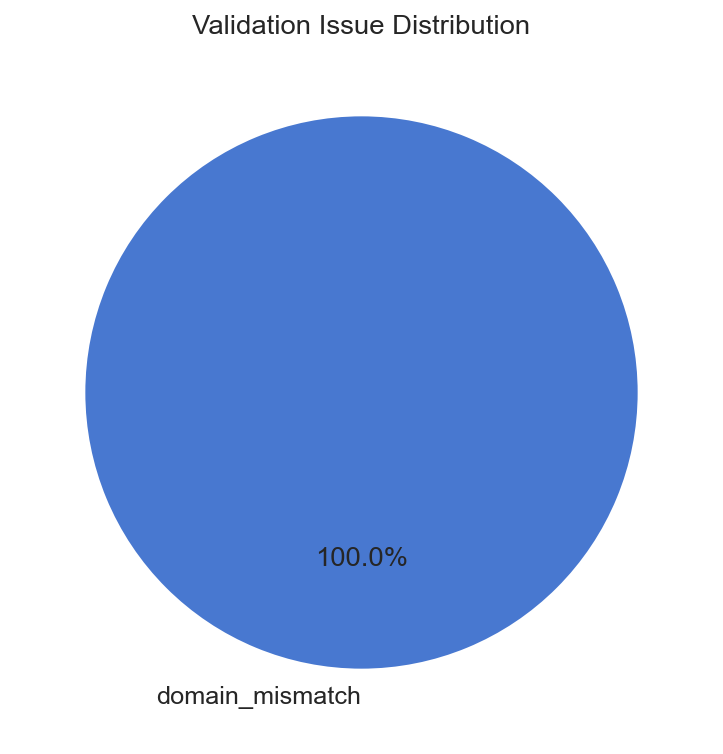


--- confidence_histogram ---


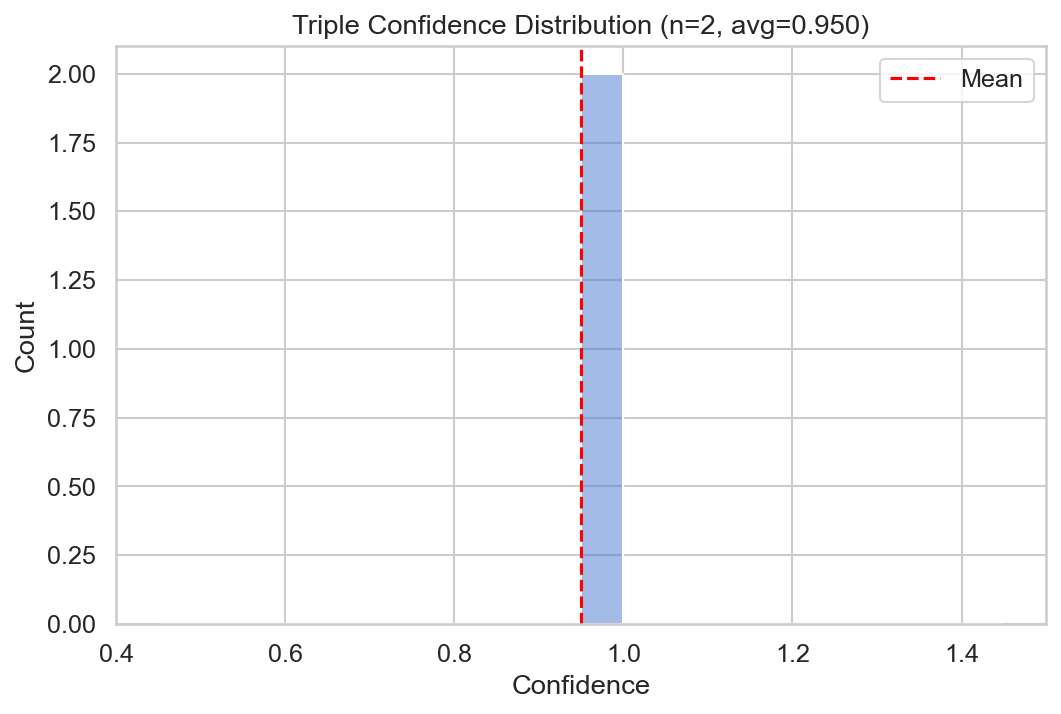


--- quality_radar ---


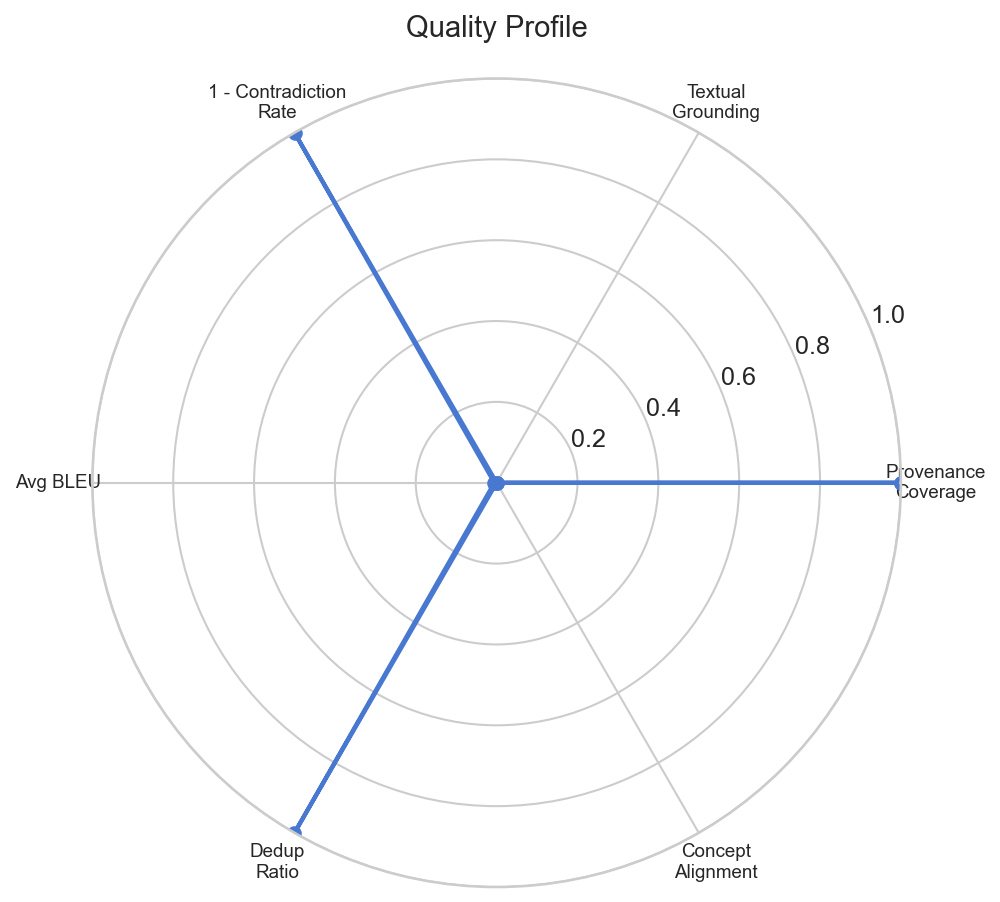


--- faithfulness_bar ---


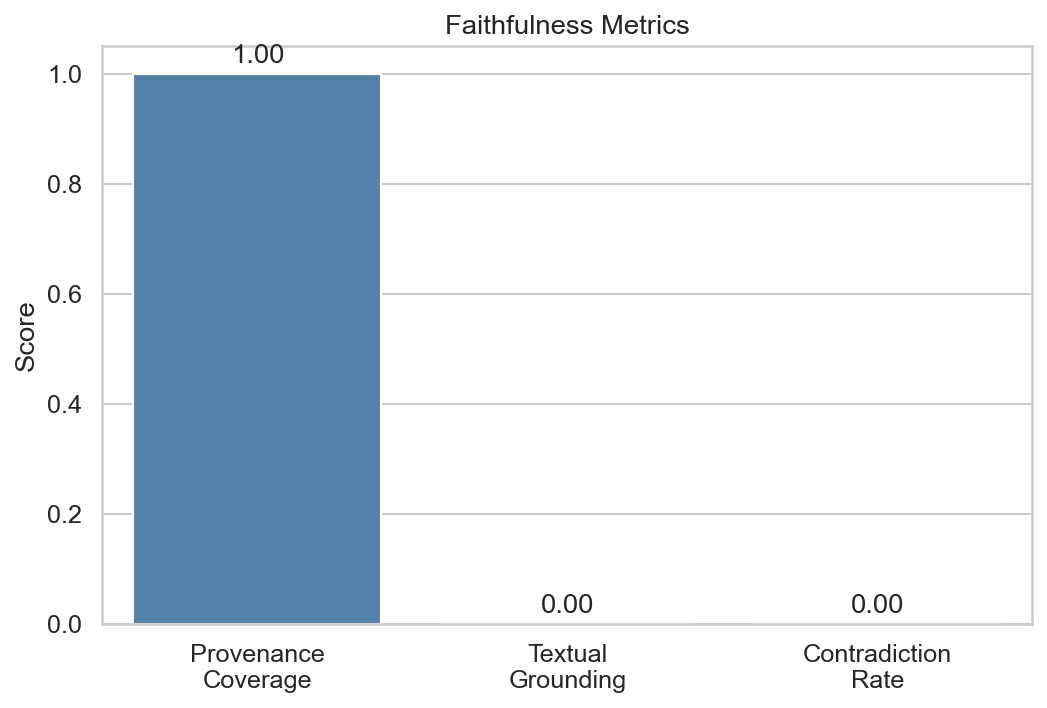

In [13]:
from IPython.display import Image, display

for p in plot_paths:
    print(f"\n--- {Path(p).stem} ---")
    display(Image(filename=p))

## 8. Detailed Metrics Export

In [14]:
all_metrics = {
    "validation": outcomes_to_dict(validation),
    "faithfulness": faithfulness_to_dict(faithfulness),
    "bleu": bleu_to_dict(bleu),
    "ontology_alignment": alignment_to_dict(alignment),
}

metrics_path = REPORTS_DIR / "all_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(all_metrics, f, indent=2, ensure_ascii=False)

print(f"All metrics saved to: {metrics_path}")
print(f"\nAll evaluation outputs in: {REPORTS_DIR.resolve()}")
for p in sorted(REPORTS_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(REPORTS_DIR)}")

All metrics saved to: evaluation_reports\all_metrics.json

All evaluation outputs in: C:\Users\Beeclick\Documents\NeoOLAF\examples\evaluation_reports
  all_metrics.json
  plots\confidence_histogram.png
  plots\faithfulness_bar.png
  plots\issues_distribution.png
  plots\quality_radar.png
  summary_report.json
  summary_report.txt
  tables_report.txt
